<a href="https://colab.research.google.com/github/mohssinehamada/Algorithmic-Trading-Bot.ipynb/blob/main/Inflation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

data = pd.read_csv('/content/API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_157.csv', skiprows=4, skipfooter=1, engine='python')
data

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,Unnamed: 68
0,Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,0.474764,-0.931196,-1.028282,3.626041,4.257462,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,5.245878,6.571396,6.399343,4.720805,4.653665,5.405162,7.240978,10.773751,7.126975,NaN
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.661709,4.383892,4.975952,0.626149,2.302373,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,2.130817,1.487416,1.725486,1.784050,1.983092,2.490378,3.745700,7.949251,4.953050,NaN
4,Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,9.355972,30.694415,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,Samoa,WSM,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,2.654867,0.689655,5.308219,2.113821,...,0.724470,1.304719,1.749897,4.197459,0.982327,-1.568912,3.133205,10.961882,NaN,NaN
261,Kosovo,XKX,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.536929,0.273169,1.488234,1.053798,2.675992,0.198228,3.353691,11.580510,4.944324,NaN
262,"Yemen, Rep.",YEM,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1.288859,2.102374,1.246285,1.337970,2.534973,4.069029,...,4.540642,6.571396,5.184247,4.517165,4.120246,3.210036,4.611672,7.039727,6.073909,NaN


In [10]:
data_filtered = data[data["Country Name"].isin(["France", "Poland"])]
data_filtered

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,Unnamed: 68
77,France,FRA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,4.139936,2.400461,5.33128,4.999153,3.211192,2.703105,...,0.037514,0.183335,1.032283,1.850815,1.108255,0.476499,1.642331,5.222367,4.878357,NaN
190,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.874126,-0.664767,2.075936,1.812952,2.227479,3.374470,5.055027,14.429451,11.528913,NaN


In [11]:
print(data_filtered.isna().sum())

Country Name      0
Country Code      0
Indicator Name    0
Indicator Code    0
1960              1
                 ..
2020              0
2021              0
2022              0
2023              0
Unnamed: 68       2
Length: 69, dtype: int64


In [17]:
data_long = pd.melt(data, id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'], var_name='Year', value_name='Value')

In [19]:
data_filtered = data_long[data_long['Country Name'].isin(['France', 'Poland'])]
data_filtered

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
77,France,FRA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,4.139936
190,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN
342,France,FRA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1961,2.400461
455,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1961,NaN
607,France,FRA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1962,5.331280
...,...,...,...,...,...,...
16620,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2022,14.429451
16772,France,FRA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2023,4.878357
16885,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2023,11.528913
17037,France,FRA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,Unnamed: 68,NaN


In [23]:
data_filtered = data_filtered.dropna(subset=['Year'])


In [24]:
data_filtered['Year'] = data_filtered['Year'].astype(int)


<ipython-input-24-5983677c02e7>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['Year'] = data_filtered['Year'].astype(int)


In [41]:
data_cleaned = data_filtered.dropna()

In [62]:
data_france = data_cleaned[data_cleaned['Country Name'] == 'France']
data_poland = data_cleaned[data_cleaned['Country Name'] == 'Poland']

In [63]:
data_france

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
77,France,FRA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,4.139936
342,France,FRA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1961,2.400461
607,France,FRA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1962,5.331280
872,France,FRA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1963,4.999153
1137,France,FRA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1964,3.211192
...,...,...,...,...,...,...
15712,France,FRA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2019,1.108255
15977,France,FRA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2020,0.476499
16242,France,FRA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2021,1.642331
16507,France,FRA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2022,5.222367


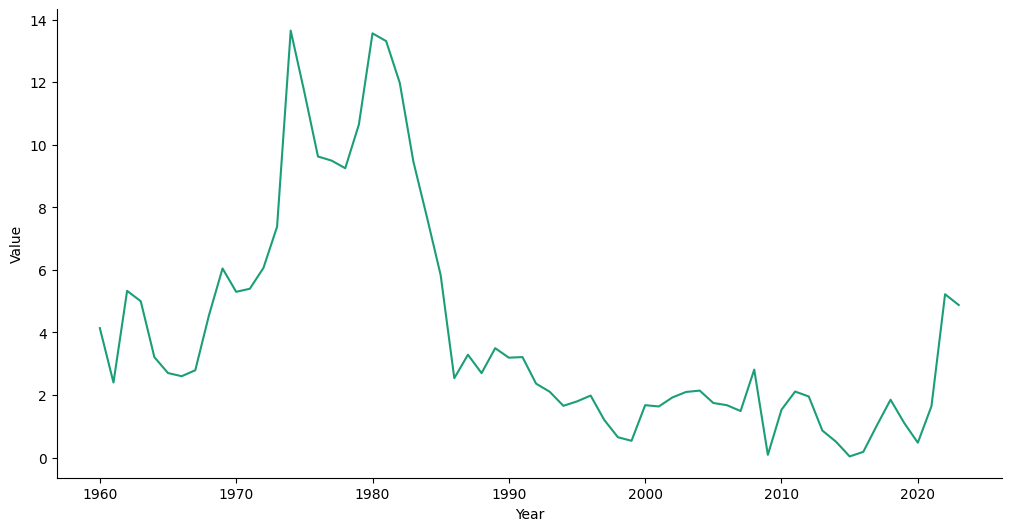

In [95]:
# @title Year vs Value

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Year']
  ys = series['Value']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = data_france.sort_values('Year', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Year')
_ = plt.ylabel('Value')

In [96]:
data_poland

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
3105,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1971,1.100000
3370,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1972,-0.098912
3635,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1973,2.475248
3900,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1974,7.053140
4165,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1975,2.256318
4430,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1976,4.413063
4695,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1977,4.902790
4960,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1978,8.101266
5225,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1979,7.025761
5490,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1980,9.682713


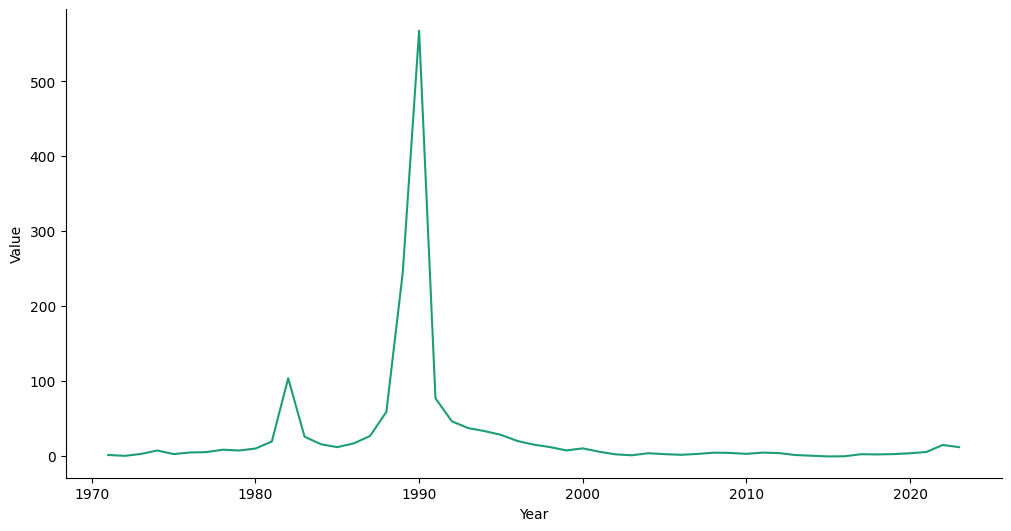

In [97]:
# @title Year vs Value

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Year']
  ys = series['Value']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = data_poland.sort_values('Year', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Year')
_ = plt.ylabel('Value')

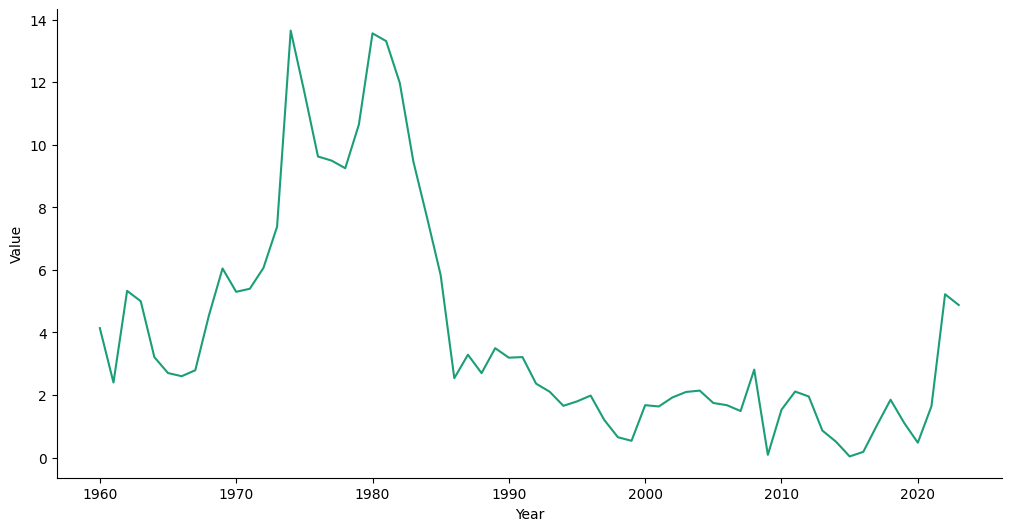

In [94]:
from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Year']
  ys = series['Value']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = data_france.sort_values('Year', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Year')
_ = plt.ylabel('Value')

In [64]:
data_poland

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
3105,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1971,1.100000
3370,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1972,-0.098912
3635,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1973,2.475248
3900,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1974,7.053140
4165,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1975,2.256318
4430,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1976,4.413063
4695,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1977,4.902790
4960,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1978,8.101266
5225,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1979,7.025761
5490,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1980,9.682713


In [25]:
data_filtered

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
77,France,FRA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,4.139936
190,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN
342,France,FRA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1961,2.400461
455,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1961,NaN
607,France,FRA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1962,5.331280
...,...,...,...,...,...,...
16355,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2021,5.055027
16507,France,FRA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2022,5.222367
16620,Poland,POL,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2022,14.429451
16772,France,FRA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2023,4.878357


In [71]:
window_size = 5

def create_sequences(data,window_size= 5 ):
  X,y = [], []
  for i in range(len(data)-window_size):
    X.append(data[i:i+window_size])
    y.append(data[i+window_size])
  return np.array(X),np.array(y)

In [69]:
# Normalize the inflation data for both countries
scaler = MinMaxScaler(feature_range=(0, 1))

In [72]:

# For France
data_france_scaled = scaler.fit_transform(data_france[['Value']].values)
X_france, y_france = create_sequences(data_france_scaled)


In [73]:
# For Poland
data_poland_scaled = scaler.fit_transform(data_poland[['Value']].values)
X_poland, y_poland = create_sequences(data_poland_scaled)

In [74]:
X_france_train, X_france_test, y_france_train, y_france_test = train_test_split(X_france, y_france, test_size=0.2, shuffle=False)
X_poland_train, X_poland_test, y_poland_train, y_poland_test = train_test_split(X_poland, y_poland, test_size=0.2, shuffle=False)


In [75]:
X_france_train = X_france_train.reshape((X_france_train.shape[0], X_france_train.shape[1], 1))
X_france_test = X_france_test.reshape((X_france_test.shape[0], X_france_test.shape[1], 1))
X_poland_train = X_poland_train.reshape((X_poland_train.shape[0], X_poland_train.shape[1], 1))
X_poland_test = X_poland_test.reshape((X_poland_test.shape[0], X_poland_test.shape[1], 1))

In [76]:
def build_and_train_model(X_train, y_train, X_test, y_test):
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=False, input_shape=(X_train.shape[1], 1)))
    model.add(Dense(units=1))  # Predicting the next year's inflation rate

    model.compile(optimizer='adam', loss='mean_squared_error')

    # Train the model
    model.fit(X_train, y_train, epochs=50, batch_size=32)

    # Evaluate the model
    loss = model.evaluate(X_test, y_test)
    print(f"Test Loss: {loss}")

    return model

In [77]:
# Train model for France
model_france = build_and_train_model(X_france_train, y_france_train, X_france_test, y_france_test)


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1969
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1823 
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1475 
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1112 
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1004 
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0804
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0606 
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0452 
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0434 
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0433 
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0386 
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0385 
Epoch 13/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0384 
Epoch 14/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0431 
Epoch 15/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0409 
Epoch 16/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/s

In [78]:
# Train model for Poland
model_poland = build_and_train_model(X_poland_train, y_poland_train, X_poland_test, y_poland_test)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0194   
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0295 
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0290 
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0200 
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0283 
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0281 
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0282 
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0282 
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0201 
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0200 
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0280 
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0266 
Epoch 13/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0201 
Epoch 14/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0279 
Epoch 15/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0278 
Epoch 16/50
2/2 ━━━━━━━━━━━━━━━━

In [81]:
def make_predictions(model, data_scaled, window_size):
    # Use the last window of data for predictions
    last_window = data_scaled[-window_size:]
    last_window = last_window.reshape((1, window_size, 1))  # Reshape for LSTM input

    # Predict for 2024
    pred_2024 = model.predict(last_window)
    pred_2024 = scaler.inverse_transform(pred_2024)  # Reverse normalization
    print(f"Predicted Inflation Rate for 2024: {pred_2024[0][0]}")

    # Predict for 2025 using the 2024 prediction
    pred_2024_reshaped = pred_2024.reshape((1, 1, 1)) # Reshape pred_2024 to have compatible dimensions
    last_window = np.append(last_window[:, 1:, :], pred_2024_reshaped, axis=1)
    pred_2025 = model.predict(last_window)
    pred_2025 = scaler.inverse_transform(pred_2025)
    print(f"Predicted Inflation Rate for 2025: {pred_2025[0][0]}")

In [83]:
# Make predictions for France
make_predictions(model_france, data_france_scaled, window_size=5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted Inflation Rate for 2024: 125.13158416748047
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predicted Inflation Rate for 2025: 1308.3360595703125


In [84]:
# Make predictions for Poland
make_predictions(model_poland, data_poland_scaled, window_size=5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
Predicted Inflation Rate for 2024: 31.685911178588867
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted Inflation Rate for 2025: 653.8046875


In [85]:
y_france_pred = model_france.predict(X_france_test)
y_france_pred_rescaled = scaler.inverse_transform(y_france_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step


In [86]:
y_poland_pred = model_poland.predict(X_poland_test)
y_poland_pred_rescaled = scaler.inverse_transform(y_poland_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step


In [98]:
def plot_predictions(actual, predicted, country_name):
    plt.figure(figsize=(10, 6))
    plt.plot(predicted, color='red', label='Predicted Inflation')
    plt.title(f"Inflation Prediction for {country_name}")
    plt.xlabel('Year')
    plt.ylabel('Inflation Rate (%)')
    plt.legend()
    plt.grid(True)
    plt.show()

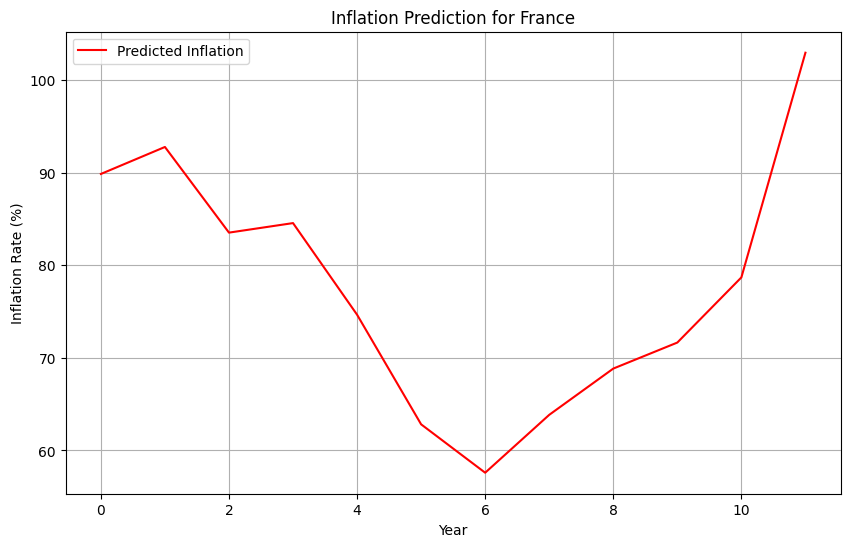

In [99]:
plot_predictions(y_france_test, y_france_pred_rescaled, "France")


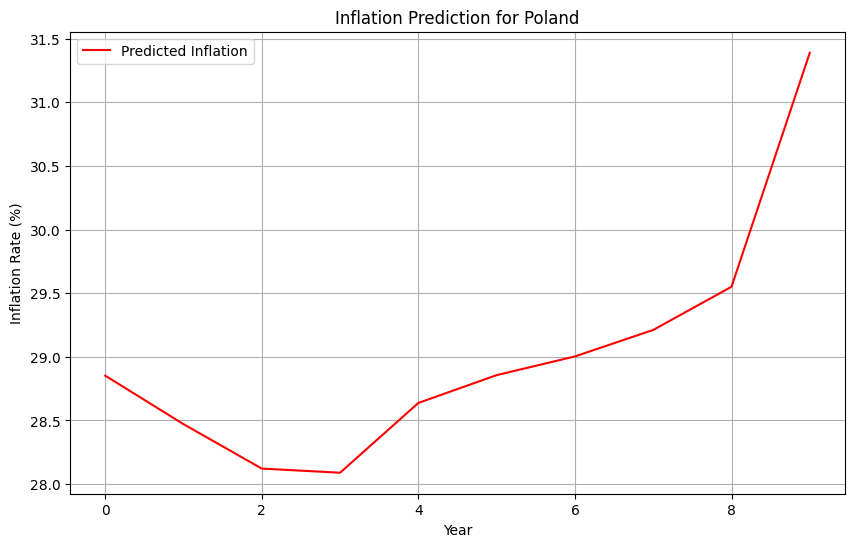

In [100]:
plot_predictions(y_poland_test, y_poland_pred_rescaled, "Poland")

#testing
